In [4]:
%pip install --upgrade pip

     ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
     ------------------------ --------------- 1.1/1.8 MB 33.9 MB/s eta 0:00:01
     ---------------------------------------- 1.8/1.8 MB 38.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.


In [ ]:
! pip install numpy pandas matplotlib seaborn librosa pillow scikit-learn tensorflow image lightgbm xgboost

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.9 MB 38.8 MB/s eta 0:00:01
     --------------- ------------------------ 4.9/12.9 MB 51.7 MB/s eta 0:00:01
     -------------------------- ------------- 8.4/12.9 MB 60.2 MB/s eta 0:00:01
     ------------------------------ -------- 10.2/12.9 MB 54.5 MB/s eta 0:00:01
     ----------------------------------- --- 11.9/12.9 MB 54.7 MB/s eta 0:00:01
     --------------------------------------  12.9/12.9 MB 50.4 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 38.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     -------------- ------------------------- 4.1/11.3 MB 86.7 MB/s eta 0:00:01
     -------------------------- ------------- 7.4/11.3 MB 95.3 MB/s eta 0:00:01
     --------------------------------------  11.3/11.3 MB 72.6 MB/s eta 0:00:01
     --------------------------------------- 11.3/11.3 M


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip list

Package            Version
------------------ ------------
absl-py            2.5.0
asgiref            3.12.1
asttokens          3.0.2
astunparse         1.6.3
audioread          3.1.0
certifi            2026.7.22
cffi               2.1.1
charset-normalizer 3.5.1
colorama           0.4.6
comm               0.2.3
contourpy          1.3.2
cycler             0.12.1
debugpy            1.8.21
decorator          5.3.1
Django             5.2.17
exceptiongroup     1.3.1
executing          2.2.1
flatbuffers        25.12.19
fonttools          4.63.0
gast               0.7.0
google-pasta       0.2.0
grpcio             1.83.1
h5py               3.14.0
idna               3.19
image              1.5.33
ipykernel          7.3.0
ipython            8.39.0
jedi               0.20.0
joblib             1.5.3
jupyter_client     8.10.0
jupyter_core       5.9.1
keras              3.12.4
kiwisolver         1.5.1
lazy-loader        0.5
libclang           18.1.1
librosa            0.11.0
llvmlite           0.49

# 1. 환경 설정

In [1]:
import os                           # 폴더 / 파일 경로 처리
import glob                         # 특정 패턴의 파일 검색 (예: .wav .mp3 등)
import random                       # 랜덤 샘플 선택
import shutil                       # 파일 복사 / 이동

import numpy as np                  # 오디오 파형, 행렬 계산
import pandas as pd                 # 데이터프레임
import matplotlib.pyplot as plt     # 그래프 (시각화)
import seaborn as sns               # confusion matrix 등 시각화
%matplotlib inline

import librosa                      # wav 로딩, waveform, FFT/STFT, Mel Spectrogram, MFCC 등 대부분 처리
import librosa.display

from PIL import Image               # 이미지 처리

from sklearn.metrics import (       # 모델 성능 평가
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 머신러닝 3종
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 분할
from sklearn.model_selection import train_test_split

# 스케일러
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 딥러닝 (CNN, CRNN, MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# Path
# =========================

BASE_DIR = os.getcwd()                                      # Jupyter Notebook에서 현재 작업 디렉토리 확인
AUDIO_DIR = os.path.join(BASE_DIR, 'audio')                 # 원본 / 전처리 Audio Data 위치
SPEC_DIR = os.path.join(BASE_DIR, 'spectrogram_data')       # 전처리된 Spectrogram Image Data 위치
SPLIT_DIR = os.path.join(BASE_DIR, 'spectrogram_split')     # Train / Val / Test 분리용 Spectrogram 위치
FEATURE_DIR = os.path.join(BASE_DIR, 'feature_data')        # Feature 저장 위치
MODEL_DIR = os.path.join(BASE_DIR, 'models')                # 모델 저장 위치 (딥러닝 3, 머신러닝 3)
TEMP_DIR = os.path.join(BASE_DIR, 'temp')                   # 보류

# =========================
# Classes
# =========================

CLASSES = ['wasp', 'bee', 'other']

# =========================
# Audio
# =========================

SR = 48000                              # 샘플 레이트
DURATION = 1.0                          # 오디오 샘플 길이 (초)
SAMPLES_PER_TRACK = int(SR * DURATION)  # 오디오 샘플 수
TARGET_DB = -20.0                       # 볼륨 정규화 기준 (dB)

# =========================
# Mel-Spectrogram
# =========================

# 이미지 크기
IMG_HEIGHT = 128
IMG_WIDTH = 128

N_FFT = 2048                            # FFT 윈도우 크기
HOP_LENGTH = 256                        # hop length (윈도우 이동 간격)
N_MELS = 128                            # mel 스펙트로그램의 mel 밴드 수

# =========================
# Training
# ========================

BATCH_SIZE = 16
EPOCHS = 50

# 2. 데이터셋 확인 및 기본 유틸리티

In [3]:
# 지정한 디렉토리가 존재하지 않으면 생성
def ensure_directory_exists(dir_path):
    os.makedirs(dir_path, exist_ok=True)

# 오디오 폴더와 클래스별 하위 폴더가 존재하는지 확인
def validate_audio_directory_structure(audio_dir, classes):
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[Error] Audio 루트 폴더를 찾을 수 없습니다. : {audio_dir}")
    
    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[Error] Class 폴더를 찾을 수 없습니다. : {class_dir}")

# 클래스 별 오디오 파일 개수를 집계하여 dict 형태로 반환
def count_audio_files(audio_dir, classes, extension = '*.wav'):
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts

# 각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
def validate_minimum_files_per_class(file_counts, minimum_count = 10):
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(f"[Error] Class '{cls}'의 Audio 파일 개수가 최소 요구량({minimum_count})보다 적습니다.")

# 파일 또는 디렉토리가 존재할 때만 삭제
def safe_remove_path(path):
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

# 오디오 속성 검증
def validate_audio_properties(audio_dir, classes, target_sr = 48000, target_duration = 1.0):
    invalid_files = []

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)

        for file_path in glob.glob(os.path.join(class_dir, '*.wav')):
            y, sr = librosa.load(file_path, sr = None, mono = True)

            duration = len(y) / sr

            if sr != target_sr or abs(duration - target_duration) > 0.01:
                invalid_files.append({
                    'file': file_path,
                    'sr': sr,
                    'duration': duration
                })
    
    return invalid_files

===== 데이터 폴더 및 파일 개수 확인 =====
Audio Root 경로:  e:\AI_First_Team_Project\Buzz\ai_model\audio
Spectrogram 저장 경로:  e:\AI_First_Team_Project\Buzz\ai_model\spectrogram_data
Split Data 저장 경로:  e:\AI_First_Team_Project\Buzz\ai_model\spectrogram_split
Feature 저장 경로:  e:\AI_First_Team_Project\Buzz\ai_model\feature_data
Model 저장 경로:  e:\AI_First_Team_Project\Buzz\ai_model\models
   Class  Count     Ratio
0   wasp    100  0.333333
1    bee    100  0.333333
2  other    100  0.333333

전체 Audio 파일 수: 300


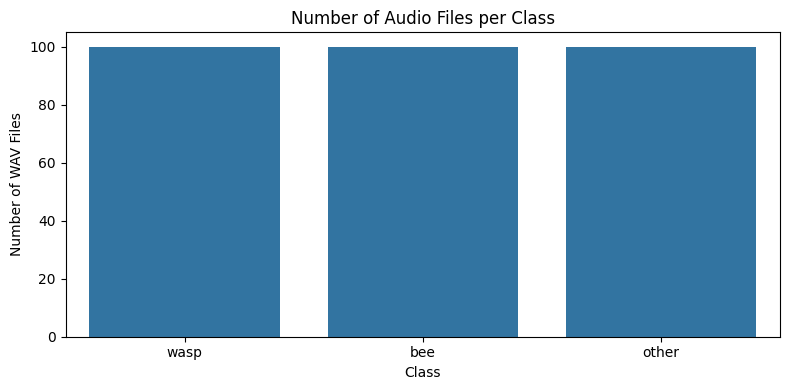

In [4]:
# Audio 폴더와 클래스 별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스 별 wav 파일 개수 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension = '*.wav')

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count = 10)

# 집계 결과를 데이터프레임으로 변환
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=['Class', 'Count'])

# 클래스 별 데이터 비율
file_counts_df['Ratio'] = (file_counts_df['Count'] / file_counts_df['Count'].sum())

# 전체 데이터 수
total_count = file_counts_df['Count'].sum()

# 현재 데이터 구성 상황
print('===== 데이터 폴더 및 파일 개수 확인 =====')
print("Audio Root 경로: ", AUDIO_DIR)
print("Spectrogram 저장 경로: ", SPEC_DIR)
print("Split Data 저장 경로: ", SPLIT_DIR)
print("Feature 저장 경로: ", FEATURE_DIR)
print("Model 저장 경로: ", MODEL_DIR)
print(file_counts_df)
print(f'\n전체 Audio 파일 수: {total_count}')

plt.figure(figsize = (8, 4))
sns.barplot(data = file_counts_df, x = "Class", y = "Count")
plt.title("Number of Audio Files per Class")
plt.xlabel("Class")
plt.ylabel("Number of WAV Files")
plt.tight_layout()
plt.show()

# 3. 오디오 전처리 및 EDA

In [5]:
'''
Audio 파일을 mono 신호로 읽고, 지정 길이와 볼륨으로 정규화한다.

- 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
- Sample Rate를 SR 기준으로 통일한다.
- Stereo 입력은 mono로 변환한다.
- 너무 긴 파일은 랜덤한 위치에서 목표 길이만큼 잘라 사용한다.
- Audio의 RMS 볼륨을 일정 수준으로 정규화한다.
- 너무 짧은 파일은 정규화 후 zero-padding 한다.
- 파일 경로 또는 코덱 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
'''

# Audio RMS 볼륨 정규화
def normalize_rms(y, target_db = TARGET_DB):
    rms = np.sqrt(np.mean(y ** 2))

    # 무음 또는 거의 무음인 경우 정규화하지 않는다.
    if rms < 1e-8:
        return y

    target_rms = 10 ** (target_db / 20)

    y = y * (target_rms / rms)

    # 증폭으로 인한 clipping 방지
    y = np.clip(y, -1.0, 1.0)

    return y

def load_audio_file(file_path, sr = SR, duration = DURATION, target_db = TARGET_DB):
    # 입력 경로 타입 확인
    if not isinstance(file_path, str):
        raise TypeError(f'[Error] file_path는 문자열이어야 합니다.\n현재 타입: {type(file_path)}')

    # 파일 존재 여부 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'[Error] Audio 파일을 찾을 수 없습니다: {file_path}')

    # 지원 확장자 확인
    valid_exts = ['.mp3', '.wav', '.flac', '.ogg', '.m4a']

    ext = os.path.splitext(file_path)[1].lower()

    if ext not in valid_exts:
        raise ValueError(f'[Error] 지원하지 않는 Audio 확장자입니다: {ext}')

    try:
        # 지정 SR로 resampling + mono 변환
        y, sr = librosa.load(file_path, sr = sr, mono = True)
    except Exception as e:
        raise RuntimeError(f'[Error] Audio Load 실패: {file_path}\n원인: {e}')

    # 빈 오디오 검사
    if y is None or len(y) == 0:
        raise ValueError(f'[Error] Audio 파일이 비어있거나 읽을 수 없습니다: {file_path}')

    # 목표 길이 계산
    target_length = int(sr * duration)

    # 긴 파일은 랜덤한 구간 사용
    if len(y) > target_length:
        max_start = len(y) - target_length
        start = random.randint(0, max_start)
        y = y[start:start + target_length]

    # 볼륨 정규화
    y = normalize_rms(y, target_db = target_db)

    # 짧은 파일은 뒤쪽 zero-padding
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode = 'constant')

    return y, sr

In [6]:
sample_files = {}

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, '*.wav')
    files = glob.glob(pattern)

    if len(files) == 0:
        raise FileNotFoundError(f"[Error] Class '{cls}'에 해당하는 Audio 파일을 찾을 수 없습니다.")

    sample_files[cls] = random.choice(files)

for cls, sample_file in sample_files.items():
    y_sample, sr_sample = load_audio_file(sample_file)

    print(f'\n===== {cls} =====')
    print('Sample File: ', sample_file)
    print('Sample Rate: ', sr_sample)
    print('Sample Counts: ', len(y_sample))
    print('Sample Duration(s): ', len(y_sample) / sr_sample)


===== wasp =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\wasp\vespa_1s_0006.wav
Sample Rate:  48000
Sample Counts:  48000
Sample Duration(s):  1.0

===== bee =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\bee\bee_2002.wav
Sample Rate:  48000
Sample Counts:  48000
Sample Duration(s):  1.0

===== other =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\other\drone_1002.wav
Sample Rate:  48000
Sample Counts:  48000
Sample Duration(s):  1.0


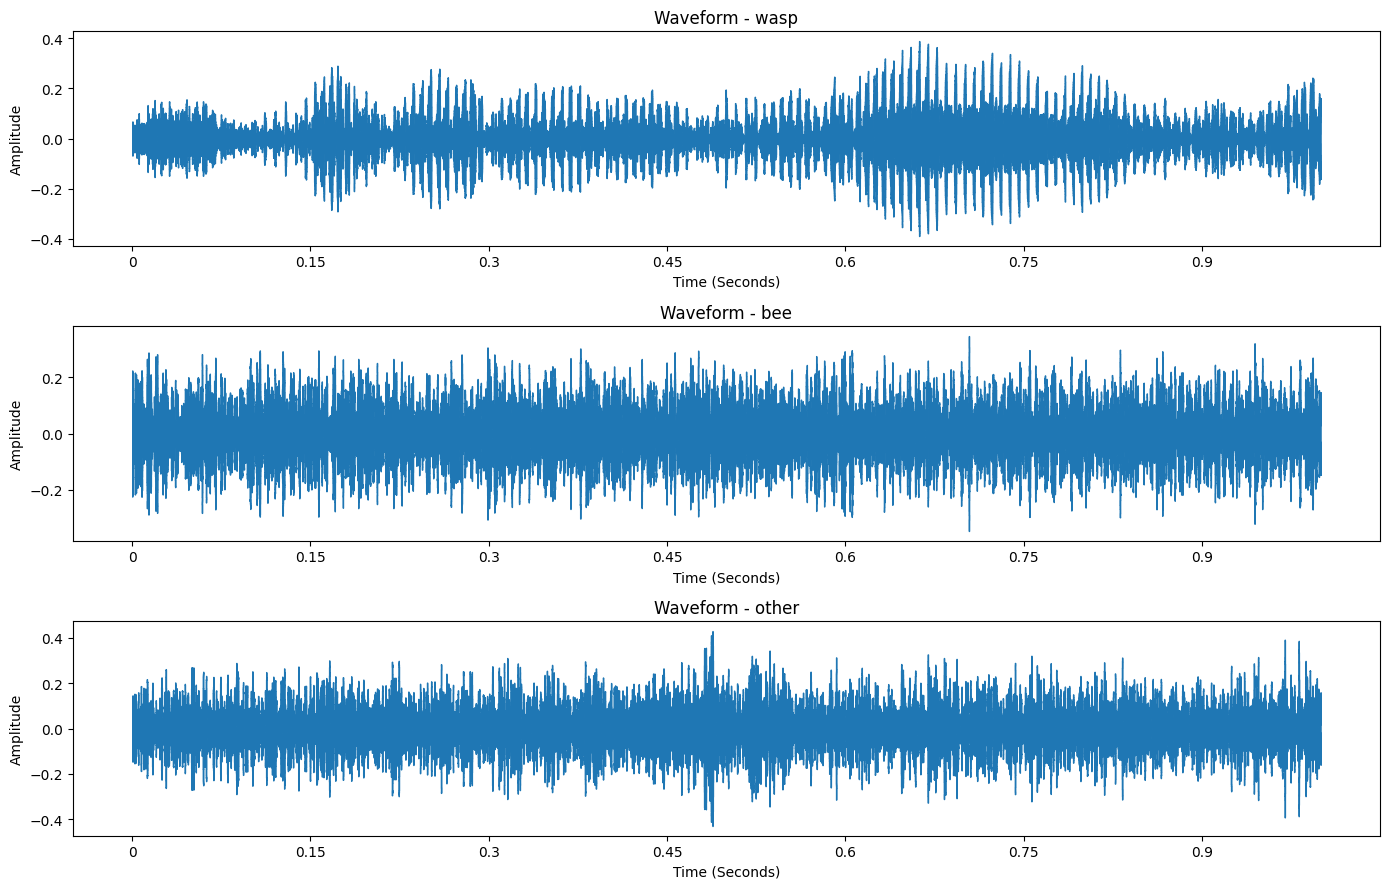

In [7]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    plt.subplot(len(CLASSES), 1, i)

    librosa.display.waveshow(y_sample, sr = sr_sample)

    plt.title(f'Waveform - {cls}')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

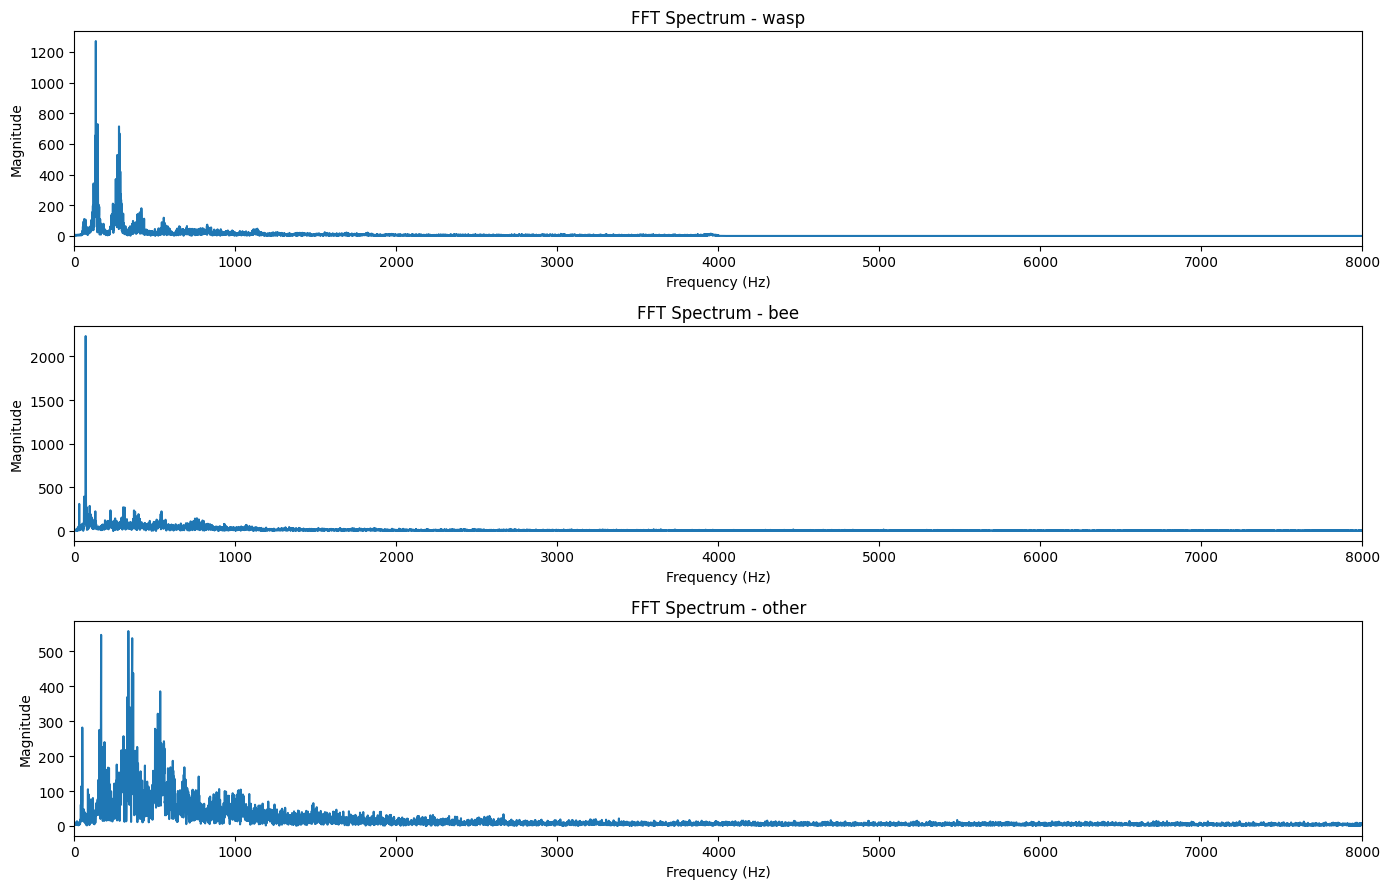

In [12]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # 실수 Audio 신호용 FFT
    fft_sample = np.fft.rfft(y_sample)

    # Magnitude Spectrum
    magnitude_sample = np.abs(fft_sample)

    # Frequency Axis
    freqs_sample = np.fft.rfftfreq(len(y_sample), d = 1 / sr_sample)

    plt.subplot(len(CLASSES), 1, i)

    plt.plot(freqs_sample, magnitude_sample)

    plt.title(f'FFT Spectrum - {cls}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    plt.xlim(0, sr_sample / 6)

plt.tight_layout()
plt.show()

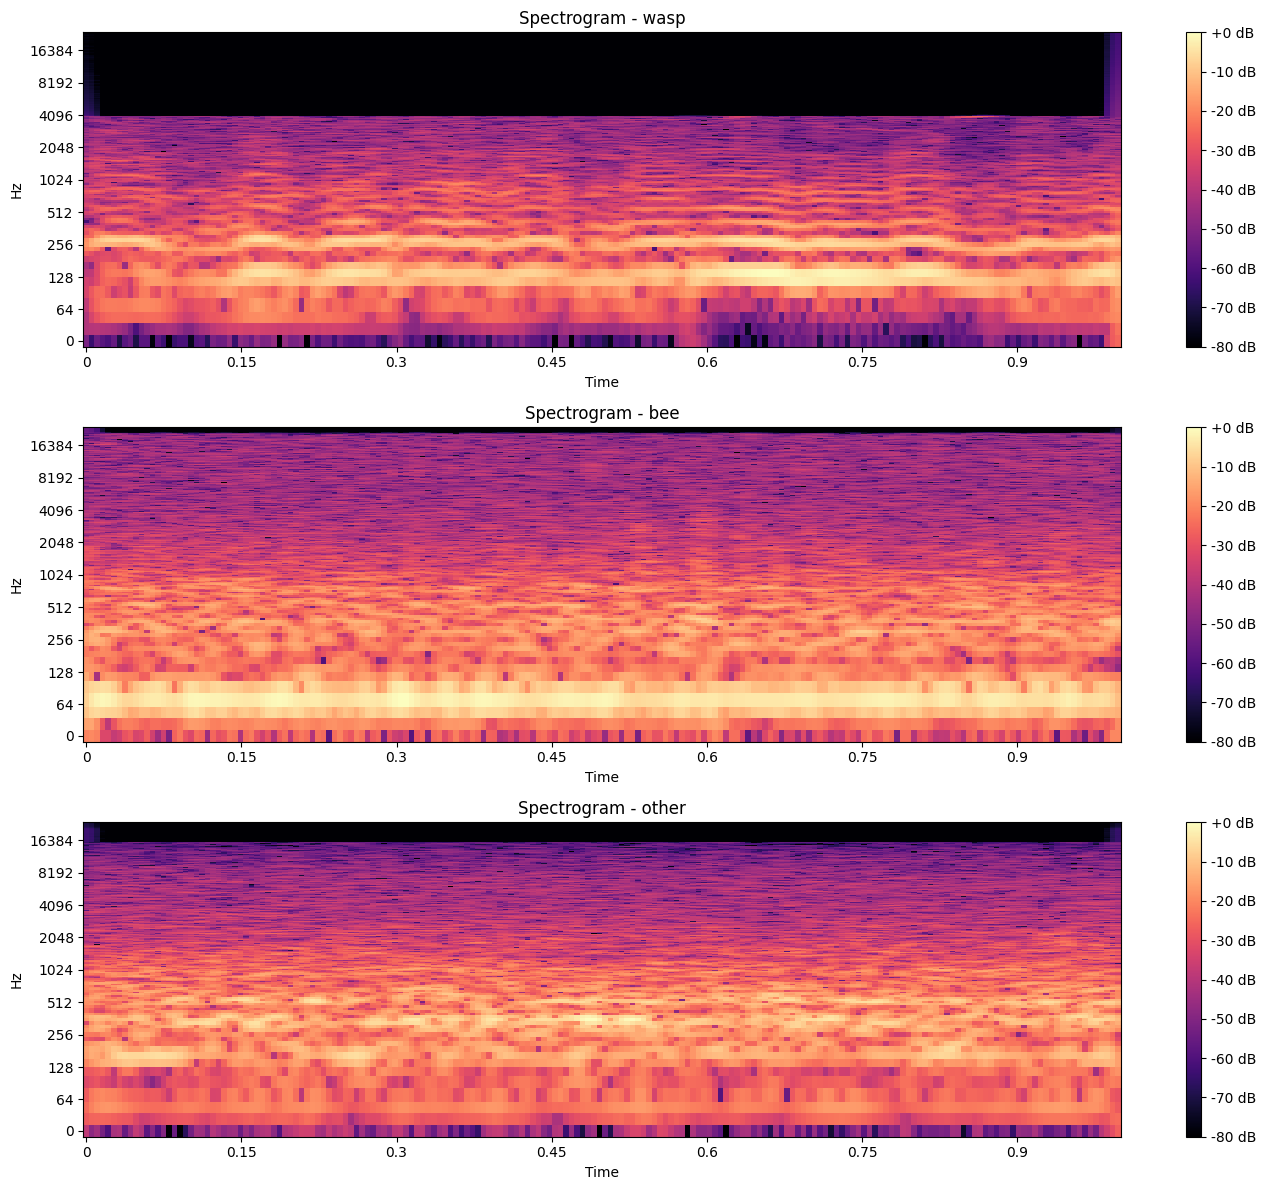

In [13]:
plt.figure(figsize = (14, 12))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # STFT
    stft_sample = librosa.stft(y_sample, n_fft = N_FFT, hop_length = HOP_LENGTH)

    # Magnitude Spectrogram
    spectrogram_sample = np.abs(stft_sample)

    # dB 변환
    spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref = np.max)

    plt.subplot(len(CLASSES), 1, i)

    img = librosa.display.specshow(
        spectrogram_db_sample,
        sr = sr_sample,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log',
        cmap = 'magma'
    )

    plt.colorbar(img, format = '%+2.0f dB')
    plt.title(f'Spectrogram - {cls}')

plt.tight_layout()
plt.show()

# 4. Mel-Spectrogram 데이터셋 구성

In [14]:
'''
Audio 파일을 Mel-Spectrogram으로 변환한다.

- CNN / MobileNet / CRNN 학습에 사용할 공통 Mel-Spectrogram을 생성한다.
- 이미지 파일(PNG)로 저장하지 않고 numpy array 형태로 저장한다.
- 학습 및 추론 과정에서 동일한 전처리 조건을 사용한다.
- 필요 시 UI의 Spectrogram 시각화 데이터로도 활용할 수 있다.
'''

def create_mel_spectrogram(audio_path, sr = SR, duration = DURATION):
    # 공통 오디오 전처리
    y, sr = load_audio_file(audio_path, sr = sr, duration = duration)

    # Mel-Spectrogram 계산
    mel_spec = librosa.feature.melspectrogram(
        y = y,
        sr = sr,
        n_fft = N_FFT,
        hop_length = HOP_LENGTH,
        n_mels = N_MELS,
        power = 2.0
    )

    # Power → dB 변환
    mel_spec_db = librosa.power_to_db(mel_spec, ref = np.max)

    return mel_spec_db

In [16]:
'''
전체 Audio 파일을 순회하며 Mel-Spectrogram Datesets 생성

- PNG 이미지 파일로 저장하지 않고 numpy 배열 형태로 구성한다.
- CNN / MobileNet / CRNN 에서 공통으로 사용할 수 있는 Mel-Spectrogram 원본 데이터를 만든다.
- Class Label과 함께 X, y 형태의 학습 Datasets을 생성한다.
'''

mel_data = []
mel_labels = []
mel_file_paths = []

print('===== Mel-Spectrogram 데이터 생성 시작 =====')

for class_index, cls in enumerate(CLASSES):
    class_audio_dir = os.path.join(AUDIO_DIR, cls)

    # Wav 파일 목록
    audio_files = glob.glob(os.path.join(class_audio_dir, '*.wav'))

    print(f'{cls}: {len(audio_files)}개 파일 처리 중...')

    for audio_file in audio_files:
        try:
            # Mel-Spectrogram 생성
            mel_spec_db = create_mel_spectrogram(audio_file)

            mel_data.append(mel_spec_db)
            mel_labels.append(class_index)
            mel_file_paths.append(audio_file)
        except Exception as e:
            print(f'[Warning] 파일 처리 실패: {audio_file}\n원인: {e}')

print('===== Mel-Spectrogram 데이터 생성 완료 =====')

# numpy 배열로 변환
X_mel = np.array(mel_data, dtype = np.float32)
y_mel = np.array(mel_labels, dtype = np.int32)
mel_file_paths = np.array(mel_file_paths)

print('Mel 데이터 shape: ', X_mel.shape)
print('Label 데이터 shape: ', y_mel.shape)
print('File Path 데이터 shape: ', mel_file_paths.shape)

===== Mel-Spectrogram 데이터 생성 시작 =====
wasp: 100개 파일 처리 중...
bee: 100개 파일 처리 중...
other: 100개 파일 처리 중...
===== Mel-Spectrogram 데이터 생성 완료 =====
Mel 데이터 shape:  (300, 128, 188)
Label 데이터 shape:  (300,)
File Path 데이터 shape:  (300,)


In [17]:
'''
Mel-Spectrogram 배열 데이터를 Train / Val / Test 로 분할

- numpy 배열 자체를 분할한다.
- Class 비율을 유지하기 위해 stratify를 적용한다.
- CNN / MobileNet / CRNN 모두 동일한 Train / Val / Test 데이터를 사용한다.
- 모델 간 비교가 공정하도록 random_state를 고정한다.
'''

# 1차 분할: Train 70%, Temp 30%
(X_train_mel, X_temp_mel, y_train_mel, y_temp_mel, paths_train_mel, paths_temp_mel) = train_test_split(
    X_mel, y_mel, mel_file_paths, test_size = 0.3, stratify = y_mel, random_state = SEED
)

# 2차 분할: Val 15%, Test 15%
(X_val_mel, X_test_mel, y_val_mel, y_test_mel, paths_val_mel, paths_test_mel) = train_test_split(
    X_temp_mel, y_temp_mel, paths_temp_mel, test_size = 0.5, stratify = y_temp_mel, random_state = SEED
)

print('===== Mel-Spectrogram 데이터 분할 완료 =====')
print('Train: ', X_train_mel.shape, y_train_mel.shape, paths_train_mel.shape)
print('Val: ', X_val_mel.shape, y_val_mel.shape, paths_val_mel.shape)
print('Test: ', X_test_mel.shape, y_test_mel.shape, paths_test_mel.shape)

def print_class_distribution(labels, dataset_name):
    unique, counts = np.unique(labels, return_counts = True)

    print(f'\n[{dataset_name}]')

    for label, count in zip(unique, counts):
        print(f'{CLASSES[label]}: {count}개')

print_class_distribution(y_train_mel, 'Train')
print_class_distribution(y_val_mel, 'Val')
print_class_distribution(y_test_mel, 'Test')

===== Mel-Spectrogram 데이터 분할 완료 =====
Train:  (210, 128, 188) (210,) (210,)
Val:  (45, 128, 188) (45,) (45,)
Test:  (45, 128, 188) (45,) (45,)

[Train]
wasp: 70개
bee: 70개
other: 70개

[Val]
wasp: 15개
bee: 15개
other: 15개

[Test]
wasp: 15개
bee: 15개
other: 15개


In [43]:
'''
딥러닝 모델 학습을 위한 Mel-Spectrogram 입력 형태 생성

- CNN 은 1채널 Spectrogram 입력을 사용한다.
- MobileNetV2 는 3채널 RGB 형태를 사용한다.
- CRNN 은 시간-주파수 구조를 최대한 유지한다.
- 동일한 Train / Val / Test Split을 사용하여 모델 간 비교 조건을 통일한다.
'''

def prepare_cnn_dataset(X):
    X = X[..., np.newaxis]
    X_resized = tf.image.resize(X, (IMG_HEIGHT, IMG_WIDTH))
    return X_resized.numpy().astype(np.float32)

def prepare_mobilenet_dataset(X):
    X = X[..., np.newaxis]
    X_resized = tf.image.resize(X, (IMG_HEIGHT, IMG_WIDTH))

    # sample별 min-max normalization
    X_min = tf.reduce_min(X_resized, axis = [1, 2, 3], keepdims = True)
    X_max = tf.reduce_max(X_resized, axis = [1, 2, 3], keepdims = True)
    X_normalized = ((X_resized - X_min) / (X_max - X_min + 1e-8))

    # 1채널 → 3채널
    X_rgb = tf.repeat(X_normalized, repeats = 3, axis = -1)

    return X_rgb.numpy().astype(np.float32)

def prepare_crnn_dataset(X):
    # 채널 차원만 추가
    X = X[..., np.newaxis]

    # Sample 별 Min-Max 정규화
    X_min = np.min(X, axis = (1, 2, 3), keepdims = True)
    X_max = np.max(X, axis = (1, 2, 3), keepdims = True)
    X_normalized = ((X - X_min) / (X_max - X_min + 1e-8))

    return X_normalized.astype(np.float32)

In [44]:
# CNN
X_train_cnn = prepare_cnn_dataset(X_train_mel)
X_val_cnn = prepare_cnn_dataset(X_val_mel)
X_test_cnn = prepare_cnn_dataset(X_test_mel)

# MobileNetV2
X_train_mobile = prepare_mobilenet_dataset(X_train_mel)
X_val_mobile = prepare_mobilenet_dataset(X_val_mel)
X_test_mobile = prepare_mobilenet_dataset(X_test_mel)

# CRNN
X_train_crnn = prepare_crnn_dataset(X_train_mel)
X_val_crnn = prepare_crnn_dataset(X_val_mel)
X_test_crnn = prepare_crnn_dataset(X_test_mel)

print('===== 딥러닝 입력 shape =====')
print('CNN : ', X_train_cnn.shape)
print('Mobile : ', X_train_mobile.shape)
print('CRNN : ', X_train_crnn.shape)

===== 딥러닝 입력 shape =====
CNN :  (210, 128, 128, 1)
Mobile :  (210, 128, 128, 3)
CRNN :  (210, 128, 188, 1)


In [20]:
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASSES)
}

idx_to_class = {
    idx: cls
    for idx, cls in enumerate(CLASSES)
}

print('class_to_idx: ', class_to_idx)
print('idx_to_class: ', idx_to_class)

class_to_idx:  {'wasp': 0, 'bee': 1, 'other': 2}
idx_to_class:  {0: 'wasp', 1: 'bee', 2: 'other'}


# 5. Deep Learning Model

## 5-1. CNN

Mel-Spectrogram을 입력으로 사용하는 CNN 분류 모델을 학습한다.

- 입력: 128 × 128 × 1 Mel-Spectrogram
- 출력 클래스: wasp / bee / other
- 평가 지표: Accuracy, Precision, Recall, Macro F1, Wasp Recall
- 최적 모델은 Validation Loss 기준으로 저장

In [21]:
'''
Mel-Spectrogram 기반 CNN 분류 모델

- 입력 : 128 x 128 크기의 1채널 Mel-Spectrogram
- 출력 : wasp / bee / other 3개 클래스 확률
'''

# CNN 입력 shape
cnn_input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

# CNN 모델 생성
cnn_model = models.Sequential([
    layers.Input(shape = cnn_input_shape),

    # 첫 번째 Convolution Layer
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution Layer
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution Layer
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 특징맵을 하나의 벡터로 축약
    layers.GlobalAveragePooling2D(),

    # 분류층
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(len(CLASSES), activation = 'softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,123 (395.01 KB)

 Trainable params: 101,123 (395.01 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
'''
CNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CNN 모델 저장 경로
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'cnn_model.keras')

# CNN 모델 컴파일
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
cnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Accuracy가 가장 높은 모델 저장
cnn_checkpoint = ModelCheckpoint(
    filepath = CNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CNN Model Path: ', CNN_MODEL_PATH)

CNN Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_model.keras


In [24]:
'''
CNN 모델 학습
'''

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_mel,
    validation_data = (X_val_cnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [cnn_early_stopping, cnn_checkpoint],
    verbose = 1
)

Epoch 1/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2672 - loss: 2.8768
Epoch 1: val_loss improved from None to 1.10442, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.2667 - loss: 2.1986 - val_accuracy: 0.3333 - val_loss: 1.1044
Epoch 2/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3273 - loss: 1.1326
Epoch 2: val_loss improved from 1.10442 to 1.08134, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.3238 - loss: 1.1378 - val_accuracy: 0.3333 - val_loss: 1.0813
Epoch 3/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3409 - loss: 1.1158
Epoch 3: val_loss improved from 1.08134 to 1.04998, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.3429 - loss: 1.0991 - val_accuracy: 0.3333 - val_loss: 1.0500
Epoc

In [ ]:
def plot_training_history(history, model_name):
    # 학습 정확도 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['accuracy'], label = 'Train Accuracy')
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

    plt.title(f'{model_name} Traning and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CNN 학습 손실 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['loss'], label = 'Train Loss')
    plt.plot(history.history['val_loss'], label = 'Validation Loss')

    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

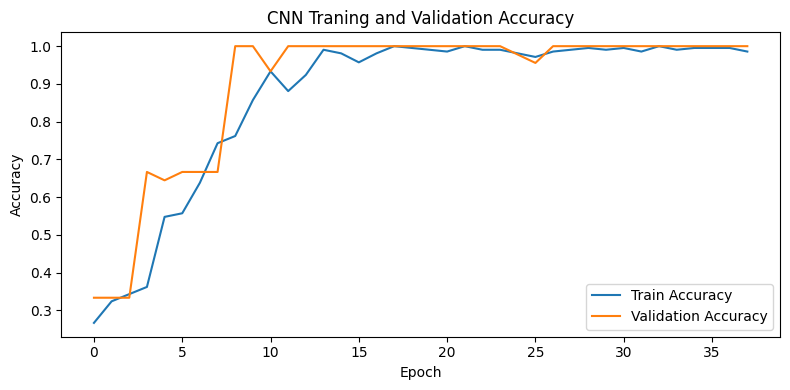

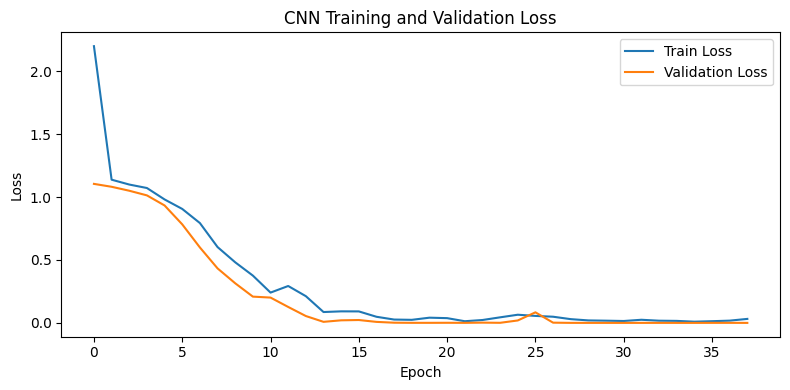

===== 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00        15
         bee       1.00      1.00      1.00        15
       other       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



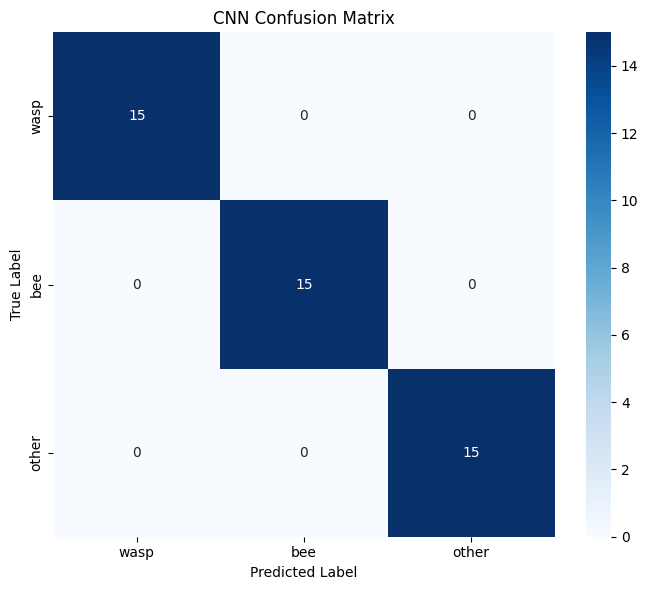

===== CNN 평가 결과 =====
Accuracy   : 1.0000
Precision  : 1.0000
Recall     : 1.0000
Macro F1   : 1.0000
Wasp Recall : 1.0000


In [40]:
'''
CNN 테스트셋 평가
'''

# 테스트셋 전체에 대해 클래스별 확률을 예측
cnn_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)

# 가장 큰 확률의 클래스를 최종 예측값으로 사용
cnn_pred_classes = np.argmax(cnn_pred_probs, axis = 1)

# 실제 정답 라벨
cnn_true_classes = y_test_mel

# 클래스 이름 목록
class_labels = CLASSES

plot_training_history(cnn_history, 'CNN')

print("===== 분류 리포트 =====")

print(classification_report(
    cnn_true_classes,
    cnn_pred_classes,
    target_names = class_labels,
    zero_division = 0
))

# Confusion Matrix
cnn_cm = confusion_matrix(cnn_true_classes, cnn_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cnn_cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_labels,
    yticklabels = class_labels
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cnn_accuracy = accuracy_score(
    cnn_true_classes,
    cnn_pred_classes
)

cnn_precision = precision_score(
    cnn_true_classes,
    cnn_pred_classes,
    average = 'macro',
    zero_division = 0
)

cnn_recall = recall_score(
    cnn_true_classes,
    cnn_pred_classes,
    average = 'macro',
    zero_division = 0
)

cnn_f1 = f1_score(
    cnn_true_classes,
    cnn_pred_classes,
    average = 'macro',
    zero_division = 0
)

cnn_wasp_recall = recall_score(
    cnn_true_classes,
    cnn_pred_classes,
    labels = [0],
    average = 'macro',
    zero_division = 0
)

print('===== CNN 평가 결과 =====')
print(f'Accuracy   : {cnn_accuracy:.4f}')
print(f'Precision  : {cnn_precision:.4f}')
print(f'Recall     : {cnn_recall:.4f}')
print(f'Macro F1   : {cnn_f1:.4f}')
print(f'Wasp Recall : {cnn_wasp_recall:.4f}')

## 5-2. MobileNetV2

사전 학습된 MobileNetV2 모델을 활용하여 Mel-Spectrogram을 분류한다

- 입력: 128 x 128 x 3 Mel-Spectrogram
- 출력 클래서: wasp / bee / other
- ImageNet 사전 학습 가중치를 활용한 Transfer Learning 사용
- MobileNetV2의 기본 특징 추출층은 동결하여 학습
- CNN 모델과 동일한 Train / Val / Test 데이터를 사용

In [27]:
'''
Mel-Spectrogram 기반 MobileNetV2 분류 모델

- ImageNet으로 사전 학습된 MobileNetV2를 특징 추출기로 사용한다.
- 데이터셋이 작기 때문에 기본 MobileNetV2 층은 동결한다.
- 마지막 분류층만 wasp / bee / other 분류에 맞게 새로 학습한다.
'''

# MobileNetV2 입력 shape
mobilenet_input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 사전 학습된 MobileNetV2 불러오기
mobilenet_base = MobileNetV2(
    input_shape = mobilenet_input_shape,
    include_top = False,
    weights = 'imagenet'
)

# 사전 학습된 특징 추출층 동결
mobilenet_base.trainable = False

# 분류 모델 구성
mobilenet_model = models.Sequential([
    layers.Input(shape = mobilenet_input_shape),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    layers.Dense(len(CLASSES), activation = 'softmax')
])

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
'''
MobileNetV2 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# MobileNetV2 모델 저장 경로
MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'mobilenetv2_best.keras')

# Model Compile
mobilenet_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
mobilenet_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
mobilenet_checkpoint = ModelCheckpoint(
    filepath = MOBILENET_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('MobileNetV2 Model Path: ', MOBILENET_MODEL_PATH)

MobileNetV2 Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras


In [29]:
'''
MobileNetV2 학습
'''

mobilenet_history = mobilenet_model.fit(
    X_train_mobile,
    y_train_mel,
    validation_data = (X_val_mobile, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [mobilenet_early_stopping, mobilenet_checkpoint],
    verbose = 1
)

Epoch 1/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6681 - loss: 0.7467
Epoch 1: val_loss improved from None to 0.10691, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 277ms/step - accuracy: 0.7667 - loss: 0.5353 - val_accuracy: 1.0000 - val_loss: 0.1069
Epoch 2/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9538 - loss: 0.1894
Epoch 2: val_loss improved from 0.10691 to 0.03831, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9762 - loss: 0.1377 - val_accuracy: 1.0000 - val_loss: 0.0383
Epoch 3/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9819 - loss: 0.0592
Epoch 3: val_loss improved from 0.03831 to 0.00988, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.9905 - loss: 0.0472 - val_accuracy: 1.0000 - val

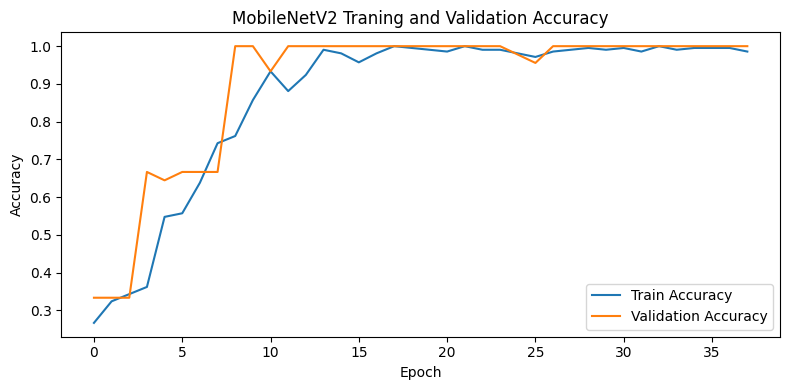

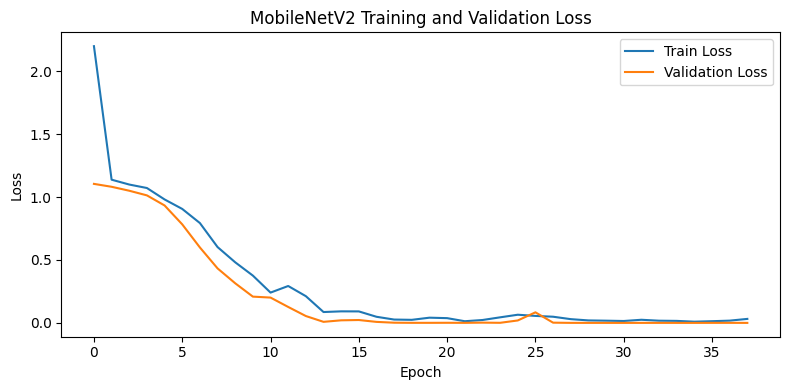

===== MobileNetV2 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00        15
         bee       1.00      1.00      1.00        15
       other       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



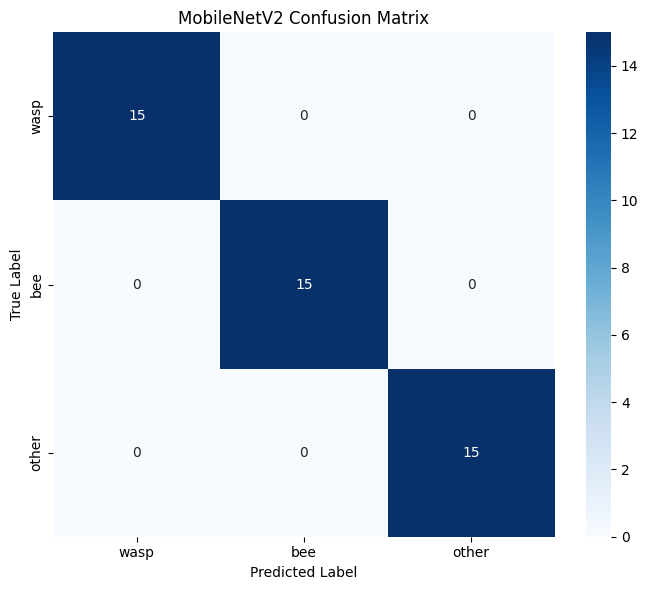

===== MobileNetV2 평가 결과 =====
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [41]:
'''
MobileNetV2 테스트셋 평가
'''

# 테스트셋 전체에 대해 클래스 별 확률 예측
mobilenet_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)

# 가장 높은 확률의 클래스를 최종 예측값으로 사용
mobilenet_pred_classes = np.argmax(mobilenet_pred_probs, axis = 1)

# 실제 정답
mobilenet_true_classes = y_test_mel

# 클래스 이름
class_labels = CLASSES

plot_training_history(mobilenet_history, 'MobileNetV2')

print('===== MobileNetV2 분류 리포트 =====')
print(classification_report(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    target_names = class_labels,
    zero_division = 0
))

# Confusion Matrix
mobilenet_cm = confusion_matrix(mobilenet_true_classes, mobilenet_pred_classes)

plt.figure(figsize = (7, 6))

sns.heatmap(
    mobilenet_cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_labels,
    yticklabels = class_labels
)

plt.title('MobileNetV2 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

mobilenet_accuracy = accuracy_score(
    mobilenet_true_classes,
    mobilenet_pred_classes
)

mobilenet_precision = precision_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average = 'macro',
    zero_division = 0
)

mobilenet_recall = recall_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average = 'macro',
    zero_division = 0
)

mobilenet_f1 = f1_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average='macro',
    zero_division=0
)

mobilenet_wasp_recall = recall_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    labels=[0],
    average='macro',
    zero_division=0
)

print("===== MobileNetV2 평가 결과 =====")
print(f"Accuracy    : {mobilenet_accuracy:.4f}")
print(f"Precision   : {mobilenet_precision:.4f}")
print(f"Recall      : {mobilenet_recall:.4f}")
print(f"Macro F1    : {mobilenet_f1:.4f}")
print(f"Wasp Recall : {mobilenet_wasp_recall:.4f}")

## 5-3. CRNN

Mel-Spectrogram의 공간적 특징과 시간적 변화를 함께 학습하기 위해 CNN과 RNN을 결합한 CRNN 모델을 구성한다.

- CNN을 통해 주파수 패턴의 특징을 추출
- RNN(GRU)을 통해 시간에 따른 특징 변화를 학습
- 출력 클래스: wasp / bee / other
- CNN, MobileNetV2와 동일한 Train / Val / Test 데이터 사용

In [45]:
'''
Mel-Spectrogram 기반 CRNN 분류 모델

- CNN으로 Mel-Spectrogram의 주요 특징을 추출한다.
- GRU를 사용하여 시간에 따른 특징 변화를 학습한다.
- wasp / bee / other 3개 클래스를 분류한다.
'''

# CRNN 입력 shape
crnn_input_shape = X_train_crnn.shape[1:]

# 입력층
crnn_input = layers.Input(shape = crnn_input_shape)

# =========================
# CNN Feature 추출
# =========================

x = layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(crnn_input)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

# =========================
# CNN → RNN 형태 변환
# =========================

# 현재 CNN 출력 shape에서 시간 축을 sequence로 사용하도록 변환
shape = x.shape

x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Dense(128, activation = 'relu')(x)

# =========================
# GRU
# =========================

x = layers.GRU(64)(x)

# =========================
# Classification
# =========================

x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

crnn_output = layers.Dense(len(CLASSES), activation = 'softmax')(x)
crnn_model = models.Model(inputs = crnn_input, outputs = crnn_output)

crnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 188, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 188, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 47, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 47, 128)        │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,691 (1.23 MB)

 Trainable params: 322,691 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
'''
CRNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CRNN 모델 저장 경로
CRNN_MODEL_PATH = os.path.join(MODEL_DIR, 'crnn_best.keras')

# 모델 컴파일
crnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
crnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
crnn_checkpoint = ModelCheckpoint(
    filepath = CRNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CRNN Model Path: ', CRNN_MODEL_PATH)

CRNN Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras


In [47]:
'''
CRNN 모델 학습
'''

crnn_history = crnn_model.fit(
    X_train_crnn,
    y_train_mel,
    validation_data = (X_val_crnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [crnn_early_stopping, crnn_checkpoint],
    verbose = 1
)

Epoch 1/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3505 - loss: 1.0079
Epoch 1: val_loss improved from None to 0.64045, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.4524 - loss: 0.9021 - val_accuracy: 0.9556 - val_loss: 0.6405
Epoch 2/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8891 - loss: 0.5508
Epoch 2: val_loss improved from 0.64045 to 0.05987, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.9333 - loss: 0.4264 - val_accuracy: 1.0000 - val_loss: 0.0599
Epoch 3/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9895 - loss: 0.0943
Epoch 3: val_loss improved from 0.05987 to 0.00274, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9952 - loss: 0.0606 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoc

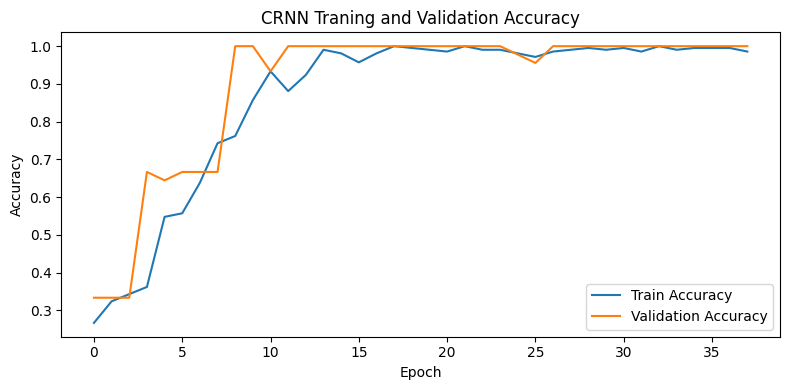

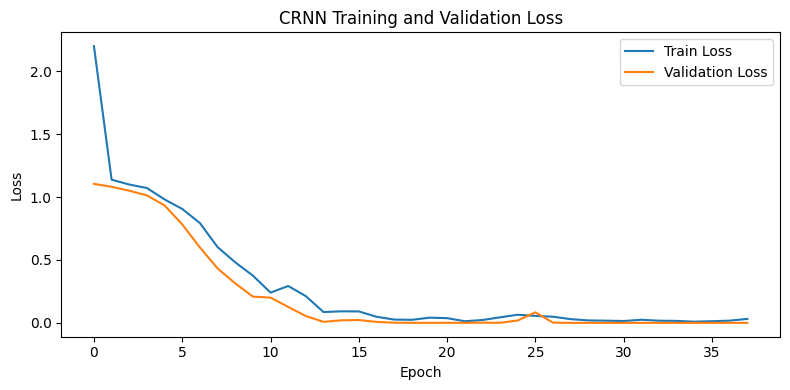

===== CRNN 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00        15
         bee       1.00      1.00      1.00        15
       other       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



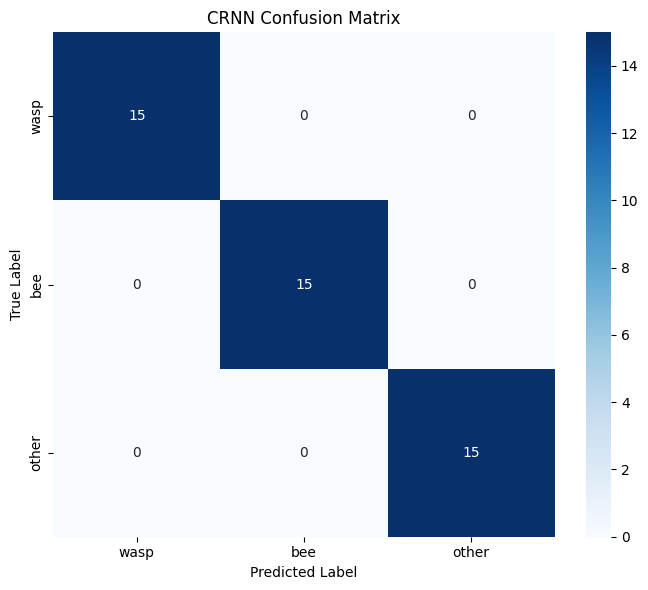

===== CRNN 평가 결과 =====
Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [48]:
'''
CRNN 테스트셋 평가
'''

# 테스트셋 전체에 대해 클래스 별 확률 예측
crnn_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)

# 가장 높은 확률의 클래스를 최종 예측값으로 사용
crnn_pred_classes = np.argmax(crnn_pred_probs, axis = 1)

# 실제 정답
crnn_true_classes = y_test_mel

# 클래스 이름
class_labels = CLASSES

plot_training_history(crnn_history, 'CRNN')

print('===== CRNN 분류 리포트 =====')

print(classification_report(
    crnn_true_classes,
    crnn_pred_classes,
    target_names = class_labels,
    zero_division = 0
))

# Confusion Matrix
crnn_cm = confusion_matrix(crnn_true_classes, crnn_pred_classes)

plt.figure(figsize = (7, 6))

sns.heatmap(
    crnn_cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_labels,
    yticklabels = class_labels
)

plt.title('CRNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

crnn_accuracy = accuracy_score(
    crnn_true_classes,
    crnn_pred_classes
)

crnn_precision = precision_score(
    crnn_true_classes,
    crnn_pred_classes,
    average = 'macro',
    zero_division = 0
)

crnn_recall = recall_score(
    crnn_true_classes,
    crnn_pred_classes,
    average = 'macro',
    zero_division = 0
)

crnn_f1 = f1_score(
    crnn_true_classes,
    crnn_pred_classes,
    average='macro',
    zero_division = 0
)

crnn_wasp_recall = recall_score(
    crnn_true_classes,
    crnn_pred_classes,
    labels=[0],
    average='macro',
    zero_division = 0
)

print("===== CRNN 평가 결과 =====")
print(f"Accuracy    : {crnn_accuracy:.4f}")
print(f"Precision   : {crnn_precision:.4f}")
print(f"Recall      : {crnn_recall:.4f}")
print(f"Macro F1    : {crnn_f1:.4f}")
print(f"Wasp Recall : {crnn_wasp_recall:.4f}")

# 6. Machine Learning Model

## 6-1. Random Forest

## 6-2. LightGBM

## 6-3. XGBoost

# 7. 모델 성능 비교 및 최종 모델 선정

학습한 모델들의 테스트 성능을 동일한 평가 지표로 비교한다.

- Accuracy
- Precision
- Recall
- Macro F1
- Wasp Recall

In [ ]:
# 학습한 모델 성능 정리
model_results = pd.DataFrame([
    {
        'Model': 'CNN',
        'Accuracy': cnn_accuracy,
        'Precision': cnn_precision,
        'Recall': cnn_recall,
        'Macro F1': cnn_f1,
        'Wasp Recall': cnn_wasp_recall
    },
    {
        'Model': 'MobileNetV2',
        'Accuracy': mobilenet_accuracy,
        'Precision': mobilenet_precision,
        'Recall': mobilenet_recall,
        'Macro F1': mobilenet_f1,
        'Wasp Recall': mobilenet_wasp_recall
    },
    {
        'Model': 'CRNN',
        'Accuracy': crnn_accuracy,
        'Precision': crnn_precision,
        'Recall': crnn_recall,
        'Macro F1': crnn_f1,
        'Wasp Recall': crnn_wasp_recall
    }
])

# Wasp Recall 기준 내림차순 정렬
model_results = model_results.sort_values(
    by = 'Wasp Recall',
    ascending = False
).reset_index(drop = True)

print('===== 모델 성능 비교 =====')
display(model_results)

best_model_name = model_results.loc[model_results['Wasp Recall'].idxmax(), 'Model']

print('===== 최종 선택 모델 =====')
print(best_model_name)

===== 모델 성능 비교 =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall
0,CNN,1.0,1.0,1.0,1.0,1.0
1,MobileNetV2,1.0,1.0,1.0,1.0,1.0


===== 최종 선택 모델 =====
CNN


# 8. 최종 추론 및 UI 데이터 생성

임의의 WAV 파일 하나를 입력받아 모델 예측 결과와
UI 시각화에 필요한 Waveform, FFT, Spectrogram 데이터를 생성한다.

반환 데이터:
- 예측 클래스
- 예측 확률
- 클래스별 확률
- Waveform
- FFT
- Mel-Spectrogram

In [ ]:
'''
UI용 분석 데이터 생성 함수
'''

def create_audio_visualization_data(audio_path, sr = SR, duration = DURATION):
    # 공통 오디오 전처리
    y, sr = load_audio_file(audio_path, sr = sr, duration = duration)

    # =========================
    # Waveform
    # =========================

    waveform_time = np.arange(len(y)) / sr

    # =========================
    # FFT
    # =========================

    fft_values = np.fft.rfft(y)
    fft_magnitude = np.abs(fft_values)
    fft_frequency = np.fft.rfftfreq(len(y), d = 1 / sr)

    # =========================
    # Mel-Spectrogram
    # =========================

    mel_spec = librosa.feature.melspectrogram(
        y = y,
        sr = sr,
        n_fft = N_FFT,
        hop_length = HOP_LENGTH,
        n_mels = N_MELS,
        power = 2.0
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref = np.max)

    # Spectrogram 시간축
    spec_times = librosa.frames_to_time(
        np.arange(mel_spec_db.shape[1]),
        sr = sr,
        hop_length = HOP_LENGTH
    )

    # Mel 주파수 축
    spec_frequencies = librosa.mel_frequencies(n_mels = N_MELS, fmin = 0, fmax = sr / 2)

    return {
        'waveform': {
            'time': waveform_time,
            'amplitude': y
        },
        'fft': {
            'frequency': fft_frequency,
            'magnitude': fft_magnitude
        },
        'spectrogram': {
            'time': spec_times,
            'frequency': spec_frequencies,
            'values': mel_spec_db
        }
    }

In [35]:
'''
CNN 추론 함수
'''

def predict_with_cnn(audio_path):
    # Mel-Spectrogram 생성
    mel_spec_db = create_mel_spectrogram(audio_path)

    # CNN 입력 형태로 변환
    cnn_input = prepare_cnn_dataset(np.array([mel_spec_db], dtype = np.float32))

    # 예측
    pred_probs = cnn_model.predict(cnn_input, verbose = 0)[0]

    pred_index = int(np.argmax(pred_probs))
    pred_class = idx_to_class[pred_index]
    confidence = float(pred_probs[pred_index])

    return {
        'prediction': pred_class,
        'confidence': confidence,
        'probabilities': {
            CLASSES[i]: float(pred_probs[i])
            for i in range(len(CLASSES))
        }
    }

In [36]:
'''
MoblieNetV2 추론 함수
'''

def predict_with_mobilenet(audio_path):
    # Mel-Spectrogram 생성
    mel_spec_db = create_mel_spectrogram(audio_path)

    # MobileNetV2 입력 형태로 변환
    mobile_input = prepare_mobilenet_dataset(np.array([mel_spec_db], dtype = np.float32))

    # 예측
    pred_probs = mobilenet_model.predict(mobile_input, verbose = 0)[0]

    pred_index = int(np.argmax(pred_probs))
    pred_class = idx_to_class[pred_index]
    confidence = float(pred_probs[pred_index])

    return {
        "prediction": pred_class,
        "confidence": confidence,
        "probabilities": {
            CLASSES[i]: float(pred_probs[i])
            for i in range(len(CLASSES))
        }
    }

In [ ]:
'''
Audio 분석
'''

def analyze_audio(audio_path, model_name = None):

    if model_name is None:
        model_name = best_model_name
    
    # =========================
    # 모델 예측
    # =========================

    if model_name == 'CNN':
        prediction_result = predict_with_cnn(audio_path)
    elif model_name == 'MobileNetV2':
        prediction_result = predict_with_mobilenet(audio_path)
    else:
        raise ValueError(f'[Error] 지원하지 않는 모델입니다: {model_name}')

    # =========================
    # UI 그래프 데이터
    # =========================

    visualization_data = create_audio_visualization_data(audio_path)

    return {
        'model': model_name,
        **prediction_result,
        **visualization_data
    }

In [ ]:
test_audio_path = ""
# os.path.join(AUDIO_DIR, 'wasp', 'wasp_001.wav') 처럼 입력하면 됨
# 랜덤 테스트 - random.choice(paths_test_mel)

result = analyze_audio(test_audio_path)

print('===== 추론 결과 =====')
print('파일: ', test_audio_path)
print('사용 모델: ', result['model'])
print('예측: ', result['prediction'])
print(f'신뢰도: {result['confidence']:.4f}')
print('클래스별 확률: ', result['probabilities'])

# 이하 코드는 일단 보류 (미사용시 삭제 예정)

In [20]:
# 신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
def visualize_audio_analysis(audio_path, predicted_class = None, probs_dict = None):
    # 오디오를 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize = (14, 4))
    librosa.display.waveshow(y, sr = sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize = (14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    plt.show()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length = HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize = (12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr = sr,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log'
    )
    plt.colorbar(format = '%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    plt.show()

    # 4) 예측 확률 막대그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class": list(probs_dict.keys()),
            "Probability": list(probs_dict.values())
        }).sort_values("Probability", ascending = False)

        plt.figure(figsize = (8, 4))
        sns.barplot(data = probs_df, x = "Class", y = "Probability")
        plt.title(f"Prediction Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation = 30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

In [ ]:
def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image = False):
    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio path는 문자열이어야 합니다.")

    # 절대경로인지 확인
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다.: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측 오디오 파일이 존재하지 않습니다.: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어있거나 유효하지 않습니다.")

    # 임시 스펙트로그램 이미지가 남아있다면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 스펙트로그램 이미지로 변환
    save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 스펙트로그램 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0 ~ 1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    img_array = np.expand_dims(img_array, axis = 0)

    # 모델 추론 수행
    probs = model.predict(img_array, verbose = 0)[0]

    # 최대 확률 클래스 인덱스 찾기
    pred_idx = int(np.argmax(probs))

    # indesx -> class 역매핑 생성
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    # 에측 클래스 이름
    predicted_class = idx_to_class_local[pred_idx]

    # 클래스별 확률 dict 생성
    probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

    # 예측용 스펙트로그램 이미지
    # plt.figure(figsize = (5, 5))
    # plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    # plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    # plt.axis('off')
    # plt.tight_layout()
    # plt.show()

    # 입력 오디오의 wave / fft / spectrogram / 확률 시각화
    # visualize_audio_analysis(
    #     audio_path = audio_path,
    #     predicted_class = predicted_class,
    #     probs_dict = probs_dict
    # )

    # 임시 저장 원하지 않으면 결과 확인 후 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, probs_dict

===== 신규 오디오 예측 준비 =====
절대경로 입력 예시:  E:\1st_project\sound\bees\part10\bee_10000.wav


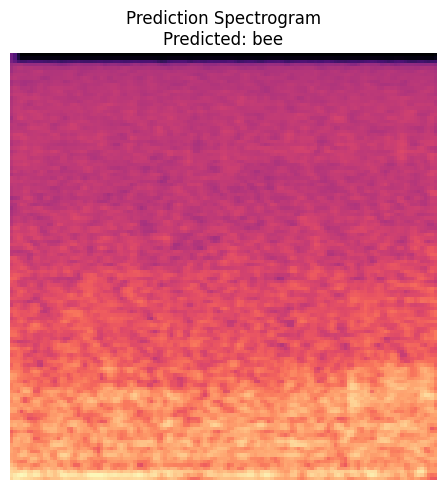

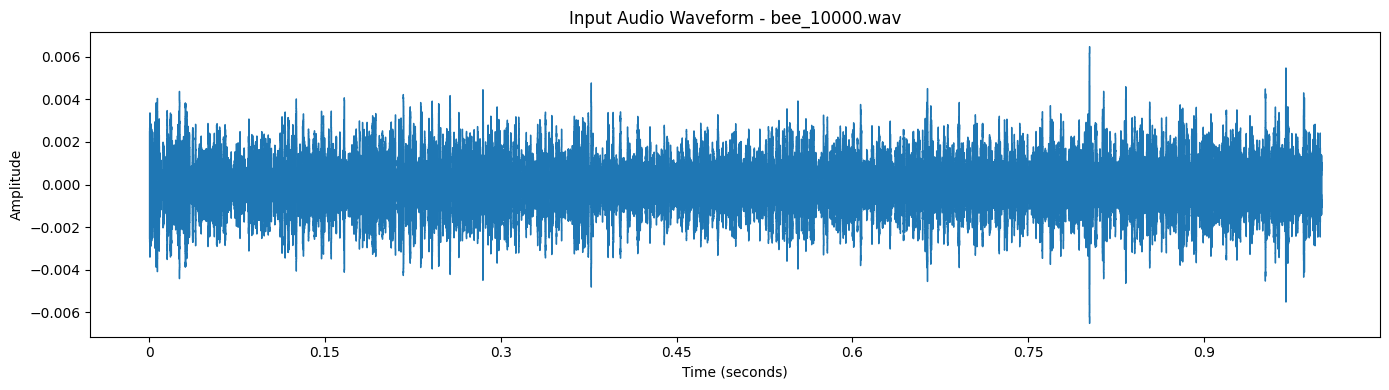

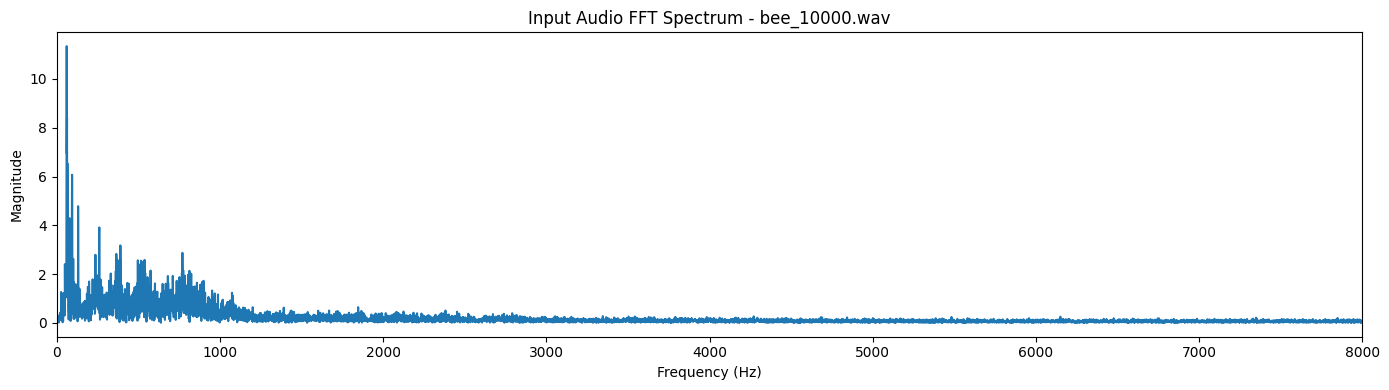

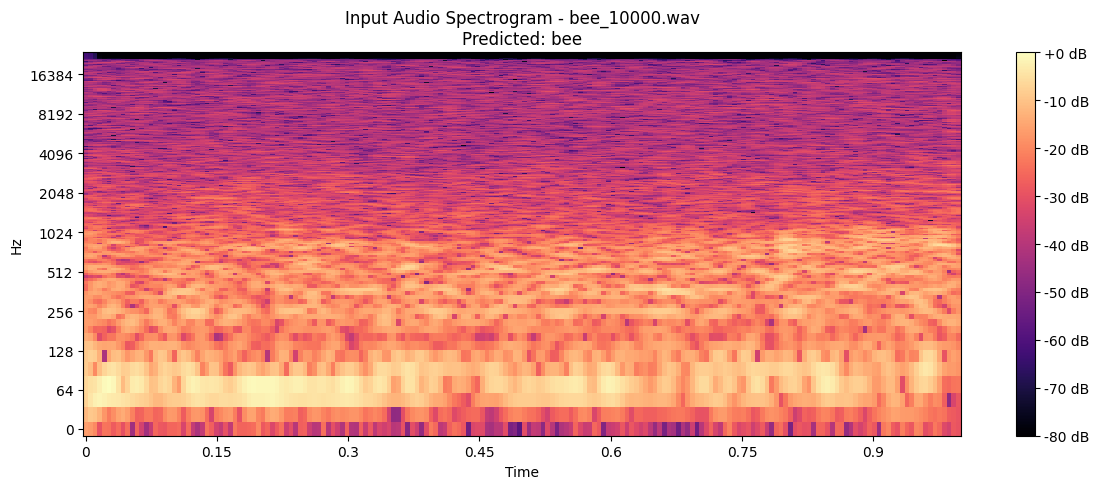

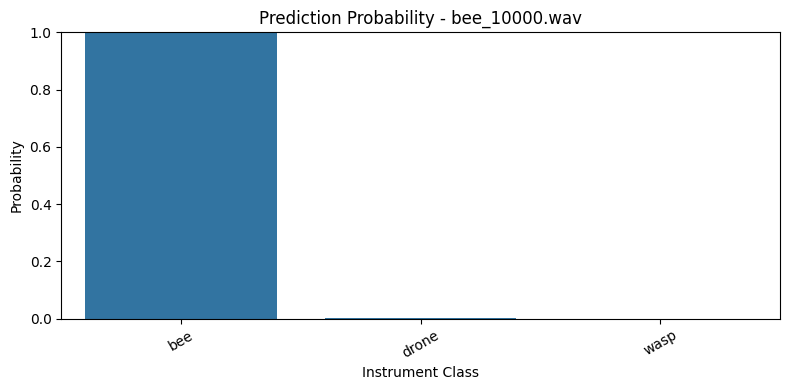


예측 클래스:  bee

클래스 별 예측 확률: 
bee: 0.9984
drone: 0.0016
wasp: 0.0000


In [22]:
NEW_AUDIO_ABSOLUTE_PATH = r"E:\1st_project\sound\bees\part10\bee_10000.wav"

print("===== 신규 오디오 예측 준비 =====")
print("절대경로 입력 예시: ", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
        audio_path = NEW_AUDIO_ABSOLUTE_PATH,
        model = model,
        class_indices = train_generator.class_indices,
        save_temp_image = False
    )

    print("\n예측 클래스: ", predicted_class)
    print("\n클래스 별 예측 확률: ")
    for cls, prob in sorted(probs_dict.items(), key = lambda x: x[1], reverse = True):
        print(f"{cls}: {prob:.4f}")

else:
    print("NEW_AUDIO_ABSOLUTE_PATH를 실제 존재하는 절대경로로 수정한 뒤 예측을 실행하세요.")

===== 신규 오디오 예측 준비 =====
절대경로 입력 예시:  E:\1st_project\sound\drones\part2\drone_1700.wav


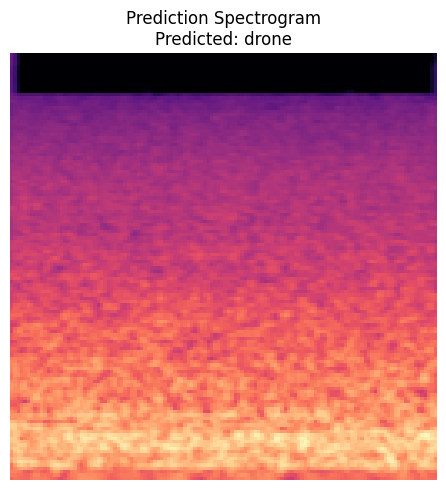

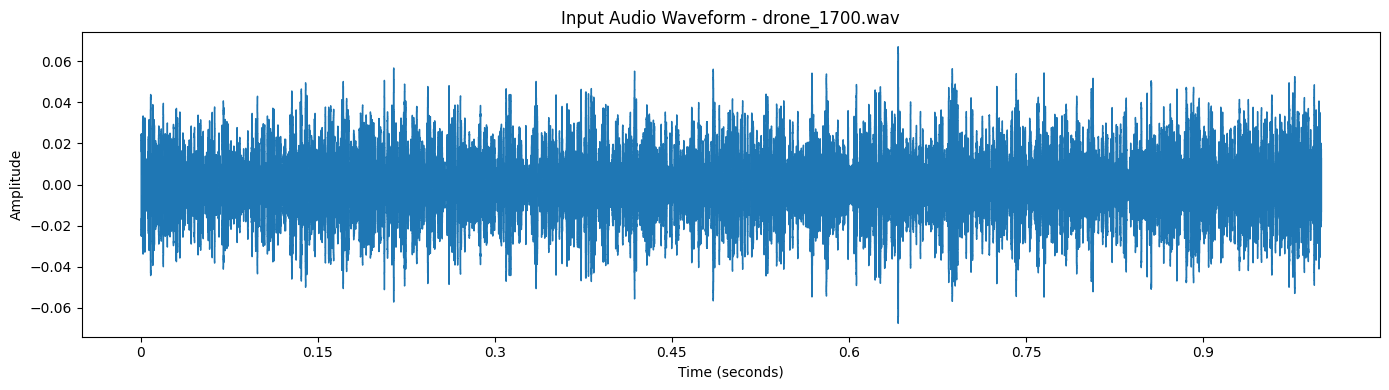

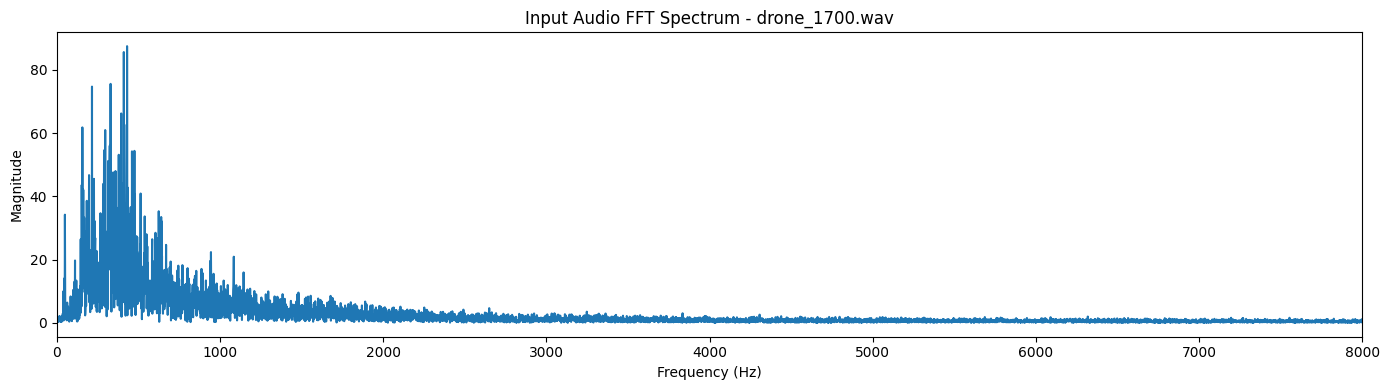

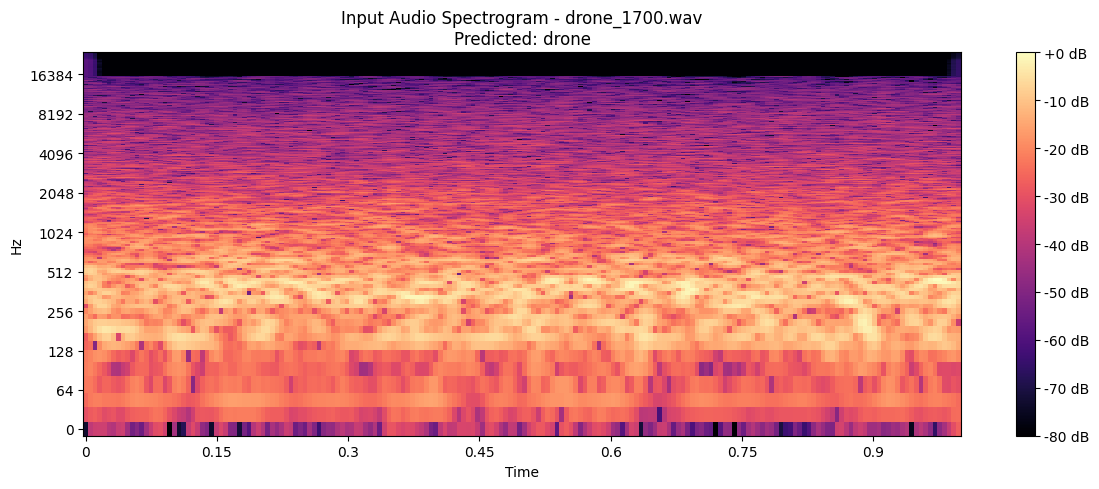

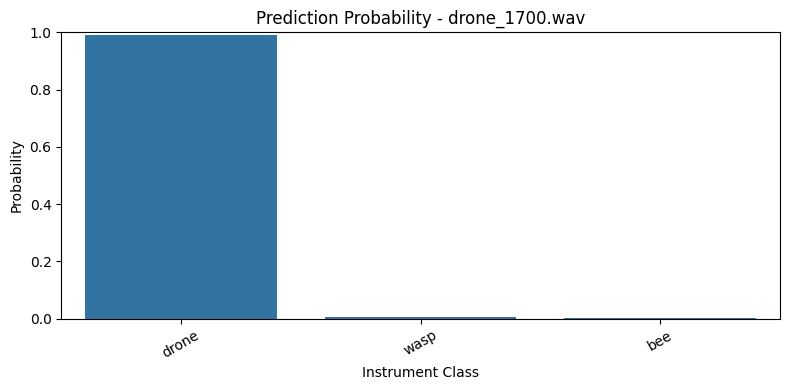


예측 클래스:  drone

클래스 별 예측 확률: 
drone: 0.9910
wasp: 0.0060
bee: 0.0030


In [23]:
NEW_AUDIO_ABSOLUTE_PATH = r"E:\1st_project\sound\drones\part2\drone_1700.wav"

print("===== 신규 오디오 예측 준비 =====")
print("절대경로 입력 예시: ", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
        audio_path = NEW_AUDIO_ABSOLUTE_PATH,
        model = model,
        class_indices = train_generator.class_indices,
        save_temp_image = False
    )

    print("\n예측 클래스: ", predicted_class)
    print("\n클래스 별 예측 확률: ")
    for cls, prob in sorted(probs_dict.items(), key = lambda x: x[1], reverse = True):
        print(f"{cls}: {prob:.4f}")

else:
    print("NEW_AUDIO_ABSOLUTE_PATH를 실제 존재하는 절대경로로 수정한 뒤 예측을 실행하세요.")

In [48]:
# shotgun 파일 하나의 절대경로를 지정하면 같은 폴더의 0001~0213 파일을 조회합니다.
NEW_AUDIO_ABSOLUTE_PATH = r"E:\1st_project\sound\temp\16-05-23_1s_clean_split\16-05-23_0001.wav"
CONFIDENCE_THRESHOLD = 0.8

split_dir = os.path.dirname(NEW_AUDIO_ABSOLUTE_PATH)
prediction_results = []
missing_files = []

for file_number in range(1, 1701):
    file_name = f"16-05-23_{file_number:04d}.wav"
    audio_path = os.path.join(split_dir, file_name)

    if not os.path.exists(audio_path):
        missing_files.append(file_name)
        continue

    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
        audio_path = audio_path,
        model = model,
        class_indices = train_generator.class_indices,
        save_temp_image = False
    )

    confidence = float(probs_dict[predicted_class])

    if confidence >= CONFIDENCE_THRESHOLD:
        result = {
            "파일명": file_name,
            "예측 클래스": predicted_class,
            "최고 확률": confidence
        }

        for class_name, probability in probs_dict.items():
            result[f"{class_name} 확률"] = float(probability)

        prediction_results.append(result)

result_df = pd.DataFrame(prediction_results)

if len(result_df) > 0:
    result_df = result_df.sort_values(
        by = "최고 확률",
        ascending = False
    ).reset_index(drop = True)

    probability_columns = [
        column for column in result_df.columns
        if "확률" in column
    ]
    result_df[probability_columns] = result_df[probability_columns].round(4)
    display(result_df)
else:
    print(f"최고 확률이 {CONFIDENCE_THRESHOLD:.1f} 이상인 파일이 없습니다.")

class_count_df = pd.DataFrame({
    "예측 클래스": CLASSES,
    "개수": [
        sum(
            result["예측 클래스"] == class_name
            for result in prediction_results
        )
        for class_name in CLASSES
    ]
})

print("\n===== 클래스별 예측 개수 (최고 확률 0.8 이상) =====")
display(class_count_df)

print("전체 조회 범위: 1700개")
print(f"조건을 만족한 파일: {len(result_df)}개")
print(f"존재하지 않는 파일: {len(missing_files)}개")

if missing_files:
    print("누락 파일:", missing_files)

,파일명,예측 클래스,최고 확률,bee 확률,drone 확률,wasp 확률
0,16-05-23_0270.wav,wasp,1.0000,0.0000,0.0000,1.0000
1,16-05-23_1522.wav,wasp,1.0000,0.0000,0.0000,1.0000
2,16-05-23_0235.wav,wasp,1.0000,0.0000,0.0000,1.0000
3,16-05-23_0181.wav,wasp,1.0000,0.0000,0.0000,1.0000
4,16-05-23_0265.wav,wasp,1.0000,0.0000,0.0000,1.0000
...,...,...,...,...,...,...
981,16-05-23_1580.wav,drone,0.8020,0.1972,0.8020,0.0008
982,16-05-23_1464.wav,drone,0.8017,0.1976,0.8017,0.0006
983,16-05-23_1342.wav,drone,0.8016,0.1978,0.8016,0.0006
984,16-05-23_1032.wav,drone,0.8010,0.1983,0.8010,0.0007



===== 클래스별 예측 개수 (최고 확률 0.8 이상) =====


,예측 클래스,개수
0,wasp,360
1,bee,3
2,drone,623


전체 조회 범위: 1700개
조건을 만족한 파일: 986개
존재하지 않는 파일: 0개
